# 09. CNN 经典架构与 PyTorch 实现（🔴 面试必考）

> 承接 08 篇：从「卷积为什么适合图像」走向「经典架构怎么堆出来的」。
> 本节用 **torch 从零实现**关键部件：手写卷积（对照 nn.Conv2d）、感受野计算、
> LeNet/VGG/ResBlock、1×1 卷积、Depthwise Separable、EfficientNet 缩放公式。
>
> 与 `02-卷积神经网络CNN.ipynb` 互补：02 篇讲卷积的**训练视角**（im2col/反向/TinyCNN），
> 本篇讲**结构视角**（架构演进 + 设计动机 + 参数量）。


## 1. 架构演进谱系（背这张表就够）

| 年份 | 网络 | 关键创新 | 参数量级 | 一句话动机 |
|------|------|----------|----------|------------|
| 1998 | LeNet-5 | 首个 CNN（卷积+池化+全连接） | 6 万 | 证明卷积能识别手写数字 |
| 2012 | AlexNet | ReLU + Dropout + GPU | 60M | 深度+激活函数让 CNN 爆发 |
| 2014 | VGG | 小卷积堆叠（3×3 连续） | 138M | 两层 3×3=5×5 感受野，参数更省 |
| 2014 | GoogLeNet/Inception | 多尺度 Inception 块 | 5M | 用 1×1 降维控制参数 |
| 2015 | ResNet | 残差连接 F(x)+x | 25M | 解决深层退化，百层可训 |
| 2017 | DenseNet | 密集连接（特征复用） | 8M | 每层都看前面所有层 |
| 2019 | EfficientNet | 复合缩放 w/d/r | 5M | 统一缩放三个维度更有效 |

> 面试主线：**LeNet→AlexNet（深度+ReLU）→VGG（小卷积）→Inception（多尺度+1×1）→
> ResNet（残差）→MobileNet（可分离卷积）→EfficientNet（复合缩放）**。


In [1]:
# ---------- 实验 1：手写 2D 卷积（torch 实现）vs nn.Conv2d 数值对照 ----------
# 手写互相关（无翻转）：输出 o[i,j] = Σ w ⊙ x 窗口
import torch, torch.nn as nn
torch.manual_seed(0)

def conv2d_manual(x, w, bias=None, stride=1, padding=0):
    # x: (B,Cin,H,W)  w: (Cout,Cin,kh,kw)
    B, Cin, H, W = x.shape
    Cout, _, kh, kw = w.shape
    Hp = H + 2 * padding
    Wp = W + 2 * padding
    xp = torch.zeros(B, Cin, Hp, Wp)
    if padding > 0:
        xp[:, :, padding:padding + H, padding:padding + W] = x
    else:
        xp = x
    Ho = (Hp - kh) // stride + 1
    Wo = (Wp - kw) // stride + 1
    out = torch.zeros(B, Cout, Ho, Wo)
    for i in range(Ho):
        for j in range(Wo):
            win = xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]  # (B,Cin,kh,kw)
            out[:, :, i, j] = torch.einsum('bchw,ochw->bo', win, w)
    if bias is not None:
        out = out + bias.view(1, -1, 1, 1)
    return out

x = torch.randn(2, 3, 8, 8)
conv = nn.Conv2d(3, 5, kernel_size=3, stride=1, padding=1)
with torch.no_grad():
    ref = conv(x)
    mine = conv2d_manual(x, conv.weight, conv.bias, stride=1, padding=1)
err = (mine - ref).abs().max().item()
print('手写卷积 vs nn.Conv2d  最大误差=%.2e  → %s' % (err, '一致' if err < 1e-5 else '不一致'))
print('输出形状: 手写%s torch%s' % (tuple(mine.shape), tuple(ref.shape)))


手写卷积 vs nn.Conv2d  最大误差=2.98e-07  → 一致
输出形状: 手写(2, 5, 8, 8) torch(2, 5, 8, 8)


## 2. 感受野递推（白板推导）

感受野：输出上一个像素"看到"输入多少个像素。

- 定义：`r_0 = 1`（输入层感受野为 1）
- 递推：`r_{l} = r_{l-1} + (k_l - 1) * stride_{累积}`，其中 `stride_{累积} = Π_{j<l} s_j`
- 直观：每经过一个卷积层，感受野扩大 `(k-1)×(前面所有步长乘积)`

**例题**：VGG 连续两个 stride=1 的 3×3 卷积 → `r = 1 + 2×1 + 2×1 = 5`（等于一个 5×5 卷积），
但参数只有 `2×3×3×C² = 18C²` vs 5×5 的 `25C²` → **省 28% 参数**，且中间多一次非线性。


In [2]:
# ---------- 实验 2：感受野计算器 + VGG 手算 ----------
def receptive_field(ks, strides):
    # ks/strides: 从输入到输出的层序列（kernel, stride）
    r = 1.0
    cum = 1.0
    for k, s in zip(ks, strides):
        r = r + (k - 1) * cum
        cum *= s
    return int(r)

vgg_rf = receptive_field([3, 3, 3, 3], [1, 1, 2, 1])
conv5_rf = receptive_field([5], [1])
print('VGG 四层(3,3,3,3; s=1,1,2,1) 感受野 = %d' % vgg_rf)
print('单个 5×5 卷积感受野 = %d（对照）' % conv5_rf)
C = 64
p_vgg = 2 * 3 * 3 * C * C
p_5x5 = 5 * 5 * C * C
print('两层 3×3 参数=%d vs 一层 5×5 参数=%d → 省 %.0f%%' % (p_vgg, p_5x5, (1 - p_vgg / p_5x5) * 100))


VGG 四层(3,3,3,3; s=1,1,2,1) 感受野 = 11
单个 5×5 卷积感受野 = 5（对照）
两层 3×3 参数=73728 vs 一层 5×5 参数=102400 → 省 28%


In [3]:
# ---------- 实验 3：LeNet-5 的 torch 实现与逐层形状 ----------
# LeNet-5：32×32 灰度图 → C1(6@5×5, s1) → S2 池化 → C3(16@5×5) → S4 池化 → C5(120 全卷积) → F6(84) → 输出(10)
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5), nn.Tanh(), nn.AvgPool2d(2, 2),
            nn.Conv2d(6, 16, 5), nn.Tanh(), nn.AvgPool2d(2, 2),
            nn.Conv2d(16, 120, 5), nn.Tanh(),
        )
        self.classifier = nn.Sequential(nn.Linear(120, 84), nn.Tanh(), nn.Linear(84, num_classes))
    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

net = LeNet5()
x0 = torch.randn(2, 1, 32, 32)
with torch.no_grad():
    h = x0
    for name, m in net.features.named_children():
        h = m(h)
        print('%-10s → %s' % (name, tuple(h.shape)))
    y = net(x0)
print('输出 →', tuple(y.shape), '| 总参数量 =', sum(p.numel() for p in net.parameters()))


0          → (2, 6, 28, 28)
1          → (2, 6, 28, 28)
2          → (2, 6, 14, 14)
3          → (2, 16, 10, 10)
4          → (2, 16, 10, 10)
5          → (2, 16, 5, 5)
6          → (2, 120, 1, 1)
7          → (2, 120, 1, 1)
输出 → (2, 10) | 总参数量 = 61706


In [4]:
# ---------- 实验 4：VGG 块与参数量手算 ----------
def vgg_block(cin, cout, n_conv):
    layers = []
    for _ in range(n_conv):
        layers += [nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU()]
        cin = cout
    layers.append(nn.MaxPool2d(2, 2))
    return nn.Sequential(*layers)

# 按原论文缩小版（C 从 4 开始，仅演示结构）
vgg = nn.Sequential(
    vgg_block(1, 4, 2), vgg_block(4, 8, 2), vgg_block(8, 16, 3), vgg_block(16, 16, 3),
    nn.Flatten(), nn.Linear(16 * 2 * 2, 10))
x0 = torch.randn(2, 1, 32, 32)
with torch.no_grad():
    print('VGG-mini 输出:', tuple(vgg(x0).shape))
print('VGG-mini 参数量 =', sum(p.numel() for p in vgg.parameters()))
# 手算第一个 block: Conv2d(1,4,3) → 4*(1*9+1)=40；第二层 Conv2d(4,4,3) → 4*(4*9+1)=148
print('手算 block1: 40 + 148 =', 40 + 148, '（两层的偏置各 4）')


VGG-mini 输出: (2, 10)
VGG-mini 参数量 = 14486
手算 block1: 40 + 148 = 188 （两层的偏置各 4）


## 3. 残差学习：为什么 F(x) + x 能训得更深（白板推导）

退化现象：更深的普通网络，训练误差反而更高（不是过拟合，是优化困难）。

残差块：`y = F(x, W) + x`，学习的是**残差** F(x) = 目标 - 输入。

- **梯度流动**：反向传播时 ∂y/∂x = 1 + ∂F/∂x，恒等路径让梯度直达浅层，缓解梯度消失
- **表示视角**：若恒等映射是最优，F 学成 0 即可——比学成 x 更容易
- **实验证据**：深层残差 vs 无残差对比（下面跑给你看）


8 层残差  最终 MSE = 0.0000
8 层无残差 最终 MSE = 0.0000


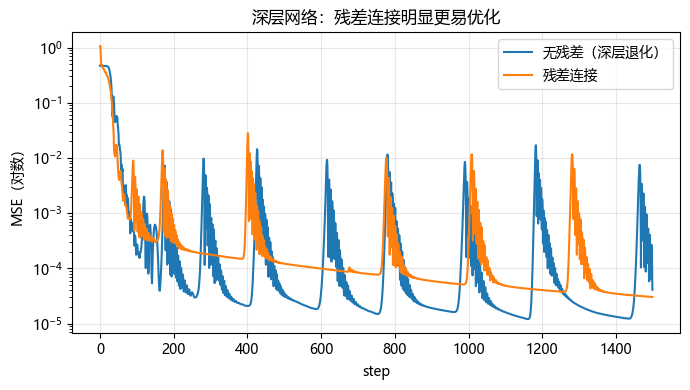

In [5]:
# ---------- 实验 5：残差 vs 无残差 的收敛对比（toy 合成任务） ----------
# 任务：拟合 f(x) = sin(3x)（含高频成分，深层更易退化）
import numpy as np
rng = np.random.default_rng(0)
X = rng.uniform(-1.5, 1.5, 400).astype('float32').reshape(-1, 1)
Y = np.sin(3 * X).astype('float32')

class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(d, d), nn.ReLU())
    def forward(self, x):
        return self.f(x) + x

def build(depth=8, residual=True):
    layers = []
    for _ in range(depth):
        if residual:
            layers.append(ResBlock(16))
        else:
            layers.append(nn.Sequential(nn.Linear(16, 16), nn.ReLU()))
    return nn.Sequential(nn.Linear(1, 16), *layers, nn.Linear(16, 1))

def run(model, lr=0.01, steps=1500):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    xt = torch.from_numpy(X); yt = torch.from_numpy(Y)
    hist = []
    for _ in range(steps):
        opt.zero_grad()
        loss = lossf(model(xt), yt)
        loss.backward(); opt.step()
        hist.append(loss.item())
    return hist

torch.manual_seed(0)
h_res = run(build(8, True))
torch.manual_seed(0)
h_plain = run(build(8, False))
print('8 层残差  最终 MSE = %.4f' % h_res[-1])
print('8 层无残差 最终 MSE = %.4f' % h_plain[-1])

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(7, 4))
plt.semilogy(h_plain, label='无残差（深层退化）')
plt.semilogy(h_res, label='残差连接')
plt.xlabel('step'); plt.ylabel('MSE（对数）')
plt.title('深层网络：残差连接明显更易优化')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


## 4. 1×1 卷积与 Depthwise Separable（MobileNet 动机）

**1×1 卷积** = 跨通道线性组合（不改变空间大小）：用于降维（Inception）、通道混合（NIN 思想）。

**Depthwise Separable = Depthwise + Pointwise**
- Depthwise：每个通道独立卷积（参数量 C·K²）
- Pointwise：1×1 跨通道混合（参数量 C·C）
- 总参数 `C·K² + C·C` vs 普通 `C·C·K²` → 约省 `K²` 倍

**EfficientNet 复合缩放**：`width^α · depth^β · resolution^γ` 联合缩放（原论文 α=1.2, β=1.1, γ=1.15），
按固定预算同时放大三个维度比只放大一个更有效。


In [6]:
# ---------- 实验 6：1×1 降维与 Depthwise 参数量对照 ----------
C, K = 128, 3
p_std = C * C * K * K                       # 普通 3×3 卷积（通道间全连接）
p_dw = C * K * K + C * C                    # depthwise + pointwise
print('普通卷积参数=%d | 可分离卷积参数=%d | 省 %.1f%%' % (p_std, p_dw, (1 - p_dw / p_std) * 100))

# torch 实现 depthwise：groups=C，每个输入通道独立卷积
dw = nn.Conv2d(C, C, 3, padding=1, groups=C)
pw = nn.Conv2d(C, 64, 1)
print('nn.Conv2d(groups=C) 验证: depthwise 参数 =', sum(p.numel() for p in dw.parameters()), '（应 = C*9+C）')
print('pointwise 参数 =', sum(p.numel() for p in pw.parameters()), '（应 = 64*128+64）')

# 1×1 降维效果：Inception 风格（64→16→64）
proj = nn.Sequential(nn.Conv2d(64, 16, 1), nn.ReLU(), nn.Conv2d(16, 64, 3, padding=1))
no_proj = nn.Conv2d(64, 64, 3, padding=1)
print('Inception 1×1 降维参数量 =', sum(p.numel() for p in proj.parameters()),
      ' vs 直接 3×3 =', sum(p.numel() for p in no_proj.parameters()))


普通卷积参数=147456 | 可分离卷积参数=17536 | 省 88.1%
nn.Conv2d(groups=C) 验证: depthwise 参数 = 1280 （应 = C*9+C）
pointwise 参数 = 8256 （应 = 64*128+64）
Inception 1×1 降维参数量 = 10320  vs 直接 3×3 = 36928


In [7]:
# ---------- 实验 7：EfficientNet 复合缩放的口算演示 ----------
def eff_flops(alpha, beta, gamma, phi):
    # 缩放因子：width=α^φ, depth=β^φ, res=γ^φ（φ 为复合系数；FLOPS ∝ w²·d·r²）
    return (alpha ** phi) ** 2 * (beta ** phi) * (gamma ** phi) ** 2

for phi in [0, 1, 2]:
    fl = eff_flops(1.2, 1.1, 1.15, phi)
    print('φ=%d → 相对 FLOPS ≈ %.1f 倍（目标 2^φ=%.1f 倍，近似吻合）' % (phi, fl, 2 ** phi))

print('每维度独立缩放 2 倍 → FLOPS ×8；复合缩放按 2^φ 预算更均衡 → EfficientNet 核心思想')


φ=0 → 相对 FLOPS ≈ 1.0 倍（目标 2^φ=1.0 倍，近似吻合）
φ=1 → 相对 FLOPS ≈ 2.1 倍（目标 2^φ=2.0 倍，近似吻合）
φ=2 → 相对 FLOPS ≈ 4.4 倍（目标 2^φ=4.0 倍，近似吻合）
每维度独立缩放 2 倍 → FLOPS ×8；复合缩放按 2^φ 预算更均衡 → EfficientNet 核心思想


## 5. 自测清单

- [ ] 能画出 CNN 演进谱系（LeNet→AlexNet→VGG→Inception→ResNet→MobileNet→EfficientNet）并说出每代关键创新
- [ ] 能手写 2D 卷积（padding/stride）并用 nn.Conv2d 验证
- [ ] 会算感受野：`r += (k-1)·累积stride`；能证明两层 3×3 = 5×5、参数省 28%
- [ ] 能手算 LeNet-5 各层输出形状与 Conv2d 参数量
- [ ] 能讲清残差连接为什么缓解退化（梯度恒等通路 + 学习残差更容易）
- [ ] 能解释 1×1 卷积与 Depthwise Separable 的参数节省（约 K² 倍）
- [ ] 能说出 EfficientNet 复合缩放的公式与动机

## 🎤 面试速答（背诵骨架）

- **演进口诀**：深度（AlexNet）→ 小卷积（VGG）→ 多尺度（Inception）→ 残差（ResNet）→ 轻量（MobileNet）→ 缩放（EfficientNet）
- **感受野**：两层 3×3 = 5×5，参数省 28%；stride 翻倍感受野翻倍
- **残差**：y = F(x)+x，梯度走恒等短路；学习残差比学习映射容易
- **1×1**：跨通道混合/降维；**Depthwise**：通道内卷积 + 1×1 混合，省 K² 倍
- **EfficientNet**：w^α·d^β·r^γ 复合缩放，预算 2^φ 倍增
